In [3]:
!pip install pytorch-lightning
!pip install arch
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.preprocessing import StandardScaler
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.loggers import CSVLogger
from torch.utils.data import Dataset, DataLoader
from scipy.stats import norm
from arch.univariate import SkewStudent

# Check if CUDA is available
print(torch.cuda.is_available())  # Should return True
class TimeseriesDataset(Dataset):
    '''
    Custom Dataset subclass.
    Serves as input to DataLoader to transform X
      into sequence data using rolling window.
    DataLoader using this dataset will output batches
      of `(batch_size, seq_len, n_features)` shape.
    Suitable as an input to RNNs.
    '''
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int = 1):
        # Remove device assignment during dataset initialization
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, index):
        return self.X[index:index + self.seq_len], self.y[index + self.seq_len - 1]
class ValueAtRiskDataModule(pl.LightningDataModule):
        '''
    PyTorch Lighting DataModule subclass:
    https://pytorch-lightning.readthedocs.io/en/latest/datamodules.html

    Serves the purpose of aggregating all data loading
      and processing work in one place.
    '''

    def __init__(self, df, training_length=1000, seq_len=1, batch_size=128, num_workers=0):
        super().__init__()
        self.df = df
        self.test_case = 0
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.preprocessing = None
        self.training_length = training_length

    def prepare_data(self):
        pass

    def move_timestep(self):
        self.test_case += 1

    def setup_train(self):
        # Get the data slice for training
        data = self.df.iloc[self.test_case:self.training_length + self.test_case]

        # Split the data into features and target
        X = data[['log_returns']].values[:self.training_length]
        y = data[['log_returns']].shift(-1).values[:self.training_length]

        # Preprocess the data using StandardScaler
        self.preprocessing = StandardScaler()
        self.preprocessing.fit(X)

        # Transform X and y, keep data on CPU for now
        self.X_train = torch.tensor(self.preprocessing.transform(X), dtype=torch.float)
        self.y_train = torch.tensor(self.preprocessing.transform(y), dtype=torch.float)

        # Prepare the test data, keep it on CPU
        self.X_test = data[['log_returns']].values[-self.seq_len - 1:-1]
        self.X_test = torch.tensor(self.preprocessing.transform(self.X_test), dtype=torch.float).unsqueeze(0)

    def train_dataloader(self):
        train_dataset = TimeseriesDataset(self.X_train, self.y_train, seq_len=self.seq_len)
        train_loader = DataLoader(train_dataset,
                                  batch_size=self.batch_size,
                                  shuffle=False,
                                  num_workers=self.num_workers)
        return train_loader

    def gather_prediction(self, prediction):
        self.df.loc[self.df.index[self.training_length + self.test_case], 'VaR'] = prediction
        print("Date: {0} -> RR: {1} | VaR: {2}".format(*(self.df.index[self.training_length + self.test_case],) + tuple(
            self.df.loc[self.df.index[self.training_length + self.test_case], ['log_returns', 'VaR']])))

import torch
import numpy as np


def caviar_loss(true, pred, pval=0.025):
    # return torch.mean(-1*((true < var).float() - pval) * (true - var))
    return torch.mean(torch.max(pval*(true - pred), (pval-1)*(true - pred)))


def huber_loss(true, var, pval=torch.tensor(0.025), eps=torch.tensor(0.025)):
    x = true - var
    return torch.mean(torch.cat([
        x[x <= (pval - 1) * eps] * (pval - 1) - 1 / 2 * (pval - 1) ** 2 * eps,
        x[(x > (pval - 1) * eps) & (x <= pval * eps)] ** 2 / (2 * eps),
        x[x > pval * eps] * pval - 1 / 2 * pval ** 2 * eps
    ]))


def garch_normal_loss(true, vol):
    return 1 / 2 * torch.mean(torch.log(vol) + true ** 2 / vol)  # + tf.math.log(2 * tf.constant(np.pi))


def student_loss(true, pred):
    vol = pred[0]
    df = pred[1] + 2

    llh = + 1/2 * (
        torch.log(vol) + (1+df)*torch.log(1 + torch.square(true)/(vol * (df - 2)))
    )

    return llh


def hansen_garch_skewed_student_loss(true, pred):

    vol = pred[:, 0]
    df = pred[:, 2]
    skewness = pred[:, 1]
    #TODO repair
    true = true[:, 0]

    c = torch.lgamma((df + 1)/2) - torch.lgamma(df / 2) - torch.log(np.pi * (df - 2)) / 2

    a = 4 * skewness * torch.exp(c) * (df-2) / (df-1)

    b = torch.sqrt(1 + 3*torch.square(skewness) - torch.square(a))

    z = true / torch.sqrt(vol)

    lls = torch.log(b) + c - torch.log(vol) / 2

    llf_resid = torch.square((b * z + a) / (1 + torch.sign(z + a / b) * skewness))

    lls -= (df + 1) / 2 * torch.log(1 + llf_resid / (df - 2))

    lls *= -1

    return torch.mean(lls)
class VaRNet(pl.LightningModule):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.criterion = criterion
        self.learning_rate = learning_rate
        self.dist = dist

        self.lstm = nn.LSTM(input_size=n_features,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True)
        self.linear = nn.Linear(hidden_size, 64)
        self.linear2 = torch.nn.Linear(64, 32)
        self.linear3 = torch.nn.Linear(32, 1)

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)
        y_pred = self.linear3(y_pred)
        return y_pred

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y, y_hat)
        self.log('train_loss', loss, on_epoch=True)
        return loss


    def predict_var(self, x):
        if self.dist is None:
            return self.forward(x).detach().numpy()
        elif isinstance(self.dist(), SkewStudent):
            var = self.forward(x).detach().numpy()[0]
            skew_student = self.dist()  # Initialize SkewStudent without parameters

            eta = max(2.05, min(var[2], 300.0))  # Clamp eta to the valid range
            lam = var[1]  # Skewness
            ppf_value = skew_student.ppf(0.025, parameters=[eta, lam])

            return np.array([np.sqrt(var[0]) * ppf_value])
        else:
            return np.sqrt(self.forward(x).detach().numpy()) * self.dist().ppf(0.025)



class GARCHVaRNet(VaRNet):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__(n_features,
                         hidden_size,
                         seq_len,
                         batch_size,
                         num_layers,
                         dropout,
                         learning_rate,
                         criterion,
                         dist)

        self.softplus = torch.nn.Softplus()

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)
        y_pred = self.linear3(y_pred)
        return self.softplus(y_pred)

class SkewedGARCHVaRNet(GARCHVaRNet):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__(n_features,
                         hidden_size,
                         seq_len,
                         batch_size,
                         num_layers,
                         dropout,
                         learning_rate,
                         criterion,
                         dist)

        self.linear3_1 = torch.nn.Linear(32, 1)
        self.linear3_2 = torch.nn.Linear(32, 1)
        self.linear3_3 = torch.nn.Linear(32, 1)

        self.tanh = torch.nn.Tanh()
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)

        y_pred_1 = self.softplus(self.linear3_1(y_pred))  # vol
        y_pred_2 = self.tanh(self.linear3_2(y_pred))  # skew
        y_pred_3 = self.relu(self.linear3_3(y_pred)) + 2.05  # df

        return torch.cat([
            y_pred_1,
            y_pred_2,
            y_pred_3
        ], 1)

import numpy as np
import pandas as pd
from scipy.optimize import minimize, differential_evolution
from sklearn.preprocessing import StandardScaler
from numba import jit, float32, int8


def strided_app(a, L, S ):  # Window len = L, Stride len/stepsize = S
    nrows = ((a.size-L)//S)+1
    n = a.strides[0]
    return np.lib.stride_tricks.as_strided(a, shape=(nrows,L), strides=(S*n,n))


def caviar(data, steps_back=1):
    scaler = StandardScaler()
    scaler.fit(data.values.reshape(-1, 1))
    data = scaler.transform(data.values.reshape(-1, 1))
    data = data.reshape(-1).astype(np.float32)
    # data = data.values.astype(np.float32)
    if len(data > 300 + steps_back - 1):
        emp_qnt = np.percentile(strided_app(data[:300 + steps_back - 1], 300, 1), 2.5, axis=-1)[-steps_back:]
    else:
        emp_qnt = np.repeat(np.quantile(data, 0.025), steps_back)
    emp_qnt = emp_qnt.astype(np.float32)

    # starting_params = np.random.random((10000, steps_back * 2 + 1)).astype(np.float32)
    #
    # res = {}
    # for params in starting_params:
    #     res[loss_numba(params, steps_back, data, emp_qnt)] = params
    #
    # best_res = {x: y for x, y in res.items() if x in sorted(res)[:10]}
    # best_params = {}
    # for params in best_res.values():
    #     res_ = minimize(loss_numba, params, args=(steps_back, data, emp_qnt), method='Nelder-Mead')
    #     res_ = minimize(loss_numba, res_.x, args=(steps_back, data, emp_qnt), method='L-BFGS-B',
    #              bounds=((-10, 10), (-10, 10)) * steps_back + ((-10, 10),))
    #     best_params[res_.fun] = res_.x
    #
    # params = best_params[sorted(best_params)[0]]
    var = np.nan
    while np.isnan(var):
        params = differential_evolution(loss_numba, args=(steps_back, data, emp_qnt), tol=0.000001,
                                        bounds=((-10, 10), (-10, 10)) * steps_back + ((-10, 10),)).x

        VaR = VaR_numba(params, steps_back, data, emp_qnt)
        var = -1 * np.sqrt(params[0] + params[1] * np.square(VaR[-1]) + params[2] * np.square(data[-1]))


    print(scaler.inverse_transform(np.array([var])))
    return scaler.inverse_transform(np.array([var]))[0]


@jit(nopython=False, nogil=True)
def loss_numba(params, steps_back, data, emp_qnt):
    VaR = np.empty(len(data), dtype=np.float32)
    VaR[0] = emp_qnt[0]

    for i in range(steps_back, len(data)):
        to_sqrt = params[0] + params[1] * np.square(VaR[i - 1]) + params[2] * np.square(data[i - 1])
        if to_sqrt < 0:
            return 100
        else:
            VaR[i] = -1 * np.sqrt(to_sqrt)

    hit = ((data < VaR) - 0.025).astype(np.float32)
    RQ = -1 * hit.dot(data - VaR)
    return RQ


@jit(nopython=False, nogil=True)
def VaR_numba(params, steps_back, data, emp_qnt):
    VaR = np.empty(len(data), dtype=np.float32)
    VaR[0] = emp_qnt[0]

    for i in range(steps_back, len(data)):
        to_sqrt = params[0] + params[1] * np.square(VaR[i - 1]) + params[2] * np.square(data[i - 1])
        VaR[i] = -1 * np.sqrt(to_sqrt)

    return VaR


def loss(params, steps_back, data, emp_qnt, VaR, pval=0.025):
    VaR[:steps_back] = emp_qnt

    for i in range(steps_back, len(data)):
        to_sqrt = params[0] + np.dot(params[1:steps_back + 1], np.square(VaR[i - (steps_back):i])) + np.dot(
            params[(steps_back + 1):(2 * steps_back + 1)], np.square(data[i - (steps_back):i]))
        if to_sqrt < 0:
            return 100
        else:
            VaR[i] = -1 * np.sqrt(to_sqrt)

    hit = (data < VaR) - np.array(pval, dtype=np.float32)
    RQ = -1 * np.sum(np.dot(hit, (data - VaR)))

    return RQ


def caviar_benchmark(index, sample_start, training_sample, testing_sample, steps_back):
    data = pd.read_csv('./data/' + index + '.csv')
    data = data.set_index(pd.to_datetime(data['Data']))
    data['log_returns'] = data['Zamkniecie'].rolling(2).apply(lambda x: np.log(x[1] / x[0]), raw=True)
    dataset = data.loc[(data.index > sample_start)]
    dataset = dataset.iloc[:(training_sample + testing_sample)]
    dataset['caviar_bench_var'] = dataset.log_returns.rolling(training_sample).apply(caviar, kwargs={
        'steps_back': steps_back}).shift(1)
    dataset.to_csv('results/' + sample_start + 'data_caviar_bench_' + index + '_' + '.csv', index=False)

def experiment_nikkei(model_name):


    # Model setup (keep this part)
    if model_name == 'garch_skew':
        model_class = SkewedGARCHVaRNet
        dist = SkewStudent
        loss = hansen_garch_skewed_student_loss
    elif model_name == 'garch_norm':
        model_class = GARCHVaRNet
        dist = norm
        loss = garch_normal_loss
    elif model_name == 'caviar':
        model_class = VaRNet
        dist = None
        loss = caviar_loss
    elif model_name == 'caviar_huber':
        model_class = VaRNet
        dist = None
        loss = huber_loss
    else:
        return

    # Data preparation
    nikkei = yf.download('^N225', start='2000-01-01')
    data = nikkei[['Close']].copy()
    data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1))
    data = data.dropna()
    data['VaR'] = np.nan

    # Use only one memory size and training period
    memory_sizes = [5]
    total_samples = len(data)
    sample_points = [int(total_samples * 0.2)]  # Use single starting point
    sample_dates = [data.index[point].strftime('%Y-%m-%d') for point in sample_points]

    for mem_size in memory_sizes:
        p = dict(
            training_length=1000,
            seq_len=mem_size,
            batch_size=512,
            criterion=loss,
            max_epochs=30,
            n_features=1,
            hidden_size=100,
            num_layers=1,
            dropout=0,
            learning_rate=3e-4,
            num_train=250
        )

        for sample_start in sample_dates:
            current_data = data.loc[(data.index > sample_start)].copy()

            dm = ValueAtRiskDataModule(
                df=current_data[['log_returns', 'VaR']],
                training_length=p['training_length'],
                seq_len=p['seq_len'],
                batch_size=p['batch_size'],
            )

            for test_case in range(p['num_train']):
                trainer = Trainer(
                    max_epochs=p['max_epochs'],
                    accelerator='auto',
                    devices=1,
                    enable_progress_bar=True
                )

                model = model_class(
                    n_features=p['n_features'],
                    hidden_size=p['hidden_size'],
                    seq_len=p['seq_len'],
                    batch_size=p['batch_size'],
                    criterion=p['criterion'],
                    num_layers=p['num_layers'],
                    dropout=p['dropout'],
                    learning_rate=p['learning_rate'],
                    dist=dist
                )

                dm.setup_train()
                trainer.fit(model, datamodule=dm)

                prediction = model.predict_var(dm.X_test)
                prediction = prediction.reshape(-1, 1) if isinstance(prediction, np.ndarray) else np.array(prediction).reshape(-1, 1)
                transformed_prediction = dm.preprocessing.inverse_transform(prediction)[0][0]
                dm.gather_prediction(transformed_prediction)
                dm.move_timestep()

            dm.df[['log_returns', 'VaR']].to_csv(f'nikkei_{model_name}_{sample_start}_{mem_size}.csv')
if __name__ == "__main__":
    experiment_nikkei('garch_skew')


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 48)

In [ ]:
class TimeseriesDataset(Dataset):
    '''
    Custom Dataset subclass.
    Serves as input to DataLoader to transform X
      into sequence data using rolling window.
    DataLoader using this dataset will output batches
      of `(batch_size, seq_len, n_features)` shape.
    Suitable as an input to RNNs.
    '''
    def __init__(self, X: np.ndarray, y: np.ndarray, seq_len: int = 1):
        # Remove device assignment during dataset initialization
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float()
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, index):
        return self.X[index:index + self.seq_len], self.y[index + self.seq_len - 1]
class ValueAtRiskDataModule(pl.LightningDataModule):
    def __init__(self, df, training_length=1000, seq_len=1, batch_size=128, num_workers=0):
        super().__init__()
        self.df = df
        self.test_case = 0
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.preprocessing = None
        self.training_length = training_length

    def prepare_data(self):
        pass

    def move_timestep(self):
        self.test_case += 1

    def setup_train(self):
        # Get the data slice for training
        data = self.df.iloc[self.test_case:self.training_length + self.test_case]

        # Split the data into features and target
        X = data[['log_returns']].values[:self.training_length]
        y = data[['log_returns']].shift(-1).values[:self.training_length]

        # Preprocess the data using StandardScaler
        self.preprocessing = StandardScaler()
        self.preprocessing.fit(X)

        # Transform X and y, keep data on CPU for now
        self.X_train = torch.tensor(self.preprocessing.transform(X), dtype=torch.float)
        self.y_train = torch.tensor(self.preprocessing.transform(y), dtype=torch.float)

        # Prepare the test data, keep it on CPU
        self.X_test = data[['log_returns']].values[-self.seq_len - 1:-1]
        self.X_test = torch.tensor(self.preprocessing.transform(self.X_test), dtype=torch.float).unsqueeze(0)

    def train_dataloader(self):
        train_dataset = TimeseriesDataset(self.X_train, self.y_train, seq_len=self.seq_len)
        train_loader = DataLoader(train_dataset,
                                  batch_size=self.batch_size,
                                  shuffle=False,
                                  num_workers=self.num_workers)
        return train_loader

    def gather_prediction(self, prediction):
        self.df.loc[self.df.index[self.training_length + self.test_case], 'VaR'] = prediction
        print("Date: {0} -> RR: {1} | VaR: {2}".format(*(self.df.index[self.training_length + self.test_case],) + tuple(
            self.df.loc[self.df.index[self.training_length + self.test_case], ['log_returns', 'VaR']])))

import torch
import numpy as np


def caviar_loss(true, pred, pval=0.025):
    # return torch.mean(-1*((true < var).float() - pval) * (true - var))
    return torch.mean(torch.max(pval*(true - pred), (pval-1)*(true - pred)))


def huber_loss(true, var, pval=torch.tensor(0.025), eps=torch.tensor(0.025)):
    x = true - var
    return torch.mean(torch.cat([
        x[x <= (pval - 1) * eps] * (pval - 1) - 1 / 2 * (pval - 1) ** 2 * eps,
        x[(x > (pval - 1) * eps) & (x <= pval * eps)] ** 2 / (2 * eps),
        x[x > pval * eps] * pval - 1 / 2 * pval ** 2 * eps
    ]))


def garch_normal_loss(true, vol):
    return 1 / 2 * torch.mean(torch.log(vol) + true ** 2 / vol)  # + tf.math.log(2 * tf.constant(np.pi))


def student_loss(true, pred):
    vol = pred[0]
    df = pred[1] + 2

    llh = + 1/2 * (
        torch.log(vol) + (1+df)*torch.log(1 + torch.square(true)/(vol * (df - 2)))
    )

    return llh


def hansen_garch_skewed_student_loss(true, pred):

    vol = pred[:, 0]
    df = pred[:, 2]
    skewness = pred[:, 1]
    #TODO repair
    true = true[:, 0]

    c = torch.lgamma((df + 1)/2) - torch.lgamma(df / 2) - torch.log(np.pi * (df - 2)) / 2

    a = 4 * skewness * torch.exp(c) * (df-2) / (df-1)

    b = torch.sqrt(1 + 3*torch.square(skewness) - torch.square(a))

    z = true / torch.sqrt(vol)

    lls = torch.log(b) + c - torch.log(vol) / 2

    llf_resid = torch.square((b * z + a) / (1 + torch.sign(z + a / b) * skewness))

    lls -= (df + 1) / 2 * torch.log(1 + llf_resid / (df - 2))

    lls *= -1

    return torch.mean(lls)


class VaRNet(pl.LightningModule):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__()
        self.n_features = n_features
        self.hidden_size = hidden_size
        self.seq_len = seq_len
        self.batch_size = batch_size
        self.num_layers = num_layers
        self.dropout = dropout
        self.criterion = criterion
        self.learning_rate = learning_rate
        self.dist = dist

        self.lstm = nn.LSTM(input_size=n_features,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout,
                            batch_first=True)
        self.linear = nn.Linear(hidden_size, 64)
        self.linear2 = torch.nn.Linear(64, 32)
        self.linear3 = torch.nn.Linear(32, 1)

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)
        y_pred = self.linear3(y_pred)
        return y_pred

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y, y_hat)
        self.log('train_loss', loss, on_epoch=True)
        return loss


    def predict_var(self, x):
        if self.dist is None:
            return self.forward(x).detach().numpy()
        elif isinstance(self.dist(), SkewStudent):
            var = self.forward(x).detach().numpy()[0]
            skew_student = self.dist()  # Initialize SkewStudent without parameters

            eta = max(2.05, min(var[2], 300.0))  # Clamp eta to the valid range
            lam = var[1]  # Skewness
            ppf_value = skew_student.ppf(0.025, parameters=[eta, lam])

            return np.array([np.sqrt(var[0]) * ppf_value])
        else:
            return np.sqrt(self.forward(x).detach().numpy()) * self.dist().ppf(0.025)



class GARCHVaRNet(VaRNet):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__(n_features,
                         hidden_size,
                         seq_len,
                         batch_size,
                         num_layers,
                         dropout,
                         learning_rate,
                         criterion,
                         dist)

        self.softplus = torch.nn.Softplus()

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)
        y_pred = self.linear3(y_pred)
        return self.softplus(y_pred)

class SkewedGARCHVaRNet(GARCHVaRNet):

    def __init__(self,
                 n_features,
                 hidden_size,
                 seq_len,
                 batch_size,
                 num_layers,
                 dropout,
                 learning_rate,
                 criterion,
                 dist):
        super().__init__(n_features,
                         hidden_size,
                         seq_len,
                         batch_size,
                         num_layers,
                         dropout,
                         learning_rate,
                         criterion,
                         dist)

        self.linear3_1 = torch.nn.Linear(32, 1)
        self.linear3_2 = torch.nn.Linear(32, 1)
        self.linear3_3 = torch.nn.Linear(32, 1)

        self.tanh = torch.nn.Tanh()
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        # lstm_out = (batch_size, seq_len, hidden_size)
        lstm_out, _ = self.lstm(x)
        y_pred = self.linear(lstm_out[:, -1])
        y_pred = self.linear2(y_pred)

        y_pred_1 = self.softplus(self.linear3_1(y_pred))  # vol
        y_pred_2 = self.tanh(self.linear3_2(y_pred))  # skew
        y_pred_3 = self.relu(self.linear3_3(y_pred)) + 2.05  # df

        return torch.cat([
            y_pred_1,
            y_pred_2,
            y_pred_3
        ], 1)

def experiment_nikkei(model_name):
    # Set the device for computations
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Model Selection
    if model_name == 'garch_skew':
        model_class = SkewedGARCHVaRNet
        dist = SkewStudent
        loss = hansen_garch_skewed_student_loss
    elif model_name == 'garch_norm':
        model_class = GARCHVaRNet
        dist = norm
        loss = garch_normal_loss
    elif model_name == 'caviar':
        model_class = VaRNet
        dist = None
        loss = caviar_loss
    elif model_name == 'caviar_huber':
        model_class = VaRNet
        dist = None
        loss = huber_loss
    else:
        return

    memory_sizes = [5]
    seed_everything(1)

    # Download and prepare Nikkei data
    nikkei = yf.download('^N225', start='2000-01-01')
    data = nikkei[['Close']].copy()
    data['log_returns'] = np.log(data['Close'] / data['Close'].shift(1))
    data = data.dropna()
    data['VaR'] = np.nan

    # Calculate training start points based on data length
    total_samples = len(data)
    sample_points = [int(total_samples * x) for x in [0.2, 0.4, 0.6, 0.8]]
    sample_dates = [data.index[point].strftime('%Y-%m-%d') for point in sample_points]

    for mem_size in memory_sizes:
        p = dict(
            training_length=1000,
            seq_len=mem_size,
            batch_size=512,
            criterion=loss,
            max_epochs=30,
            n_features=1,
            hidden_size=100,
            num_layers=1,
            dropout=0,
            learning_rate=3e-4,
            num_train=250
        )

        for sample_start in sample_dates:
            current_data = data.loc[(data.index > sample_start)].copy()

            # Initialize DataModule
            dm = ValueAtRiskDataModule(
                df=current_data[['log_returns', 'VaR']],
                training_length=p['training_length'],
                seq_len=p['seq_len'],
                batch_size=p['batch_size'],
            )
            dm.setup_train()

            for test_case in range(p['num_train']):
                # Set up the logger and trainer
                csv_logger = CSVLogger(
                    './runs/',
                    name=f'nikkei_{model_name}_{mem_size}_{sample_start}',
                    version=str(test_case)
                )

                trainer = Trainer(
                    max_epochs=p['max_epochs'],
                    logger=csv_logger,
                    accelerator='auto',
                    devices=1,
                    strategy='auto',
                    enable_progress_bar=True
                )

                # Instantiate the model and move it to the correct device
                model = model_class(
                    n_features=p['n_features'],
                    hidden_size=p['hidden_size'],
                    seq_len=p['seq_len'],
                    batch_size=p['batch_size'],
                    criterion=p['criterion'],
                    num_layers=p['num_layers'],
                    dropout=p['dropout'],
                    learning_rate=p['learning_rate'],
                    dist=dist
                ).to(device)

                # Fit the model using PyTorch Lightning
                # Move batch data to the correct device within the training loop
                for batch_idx, (x, y) in enumerate(dm.train_dataloader()):
                    x, y = x.to(device), y.to(device)

                trainer.fit(model, datamodule=dm)

                # Move test data to the device and get predictions
                X_test = dm.X_test.to(device)
                prediction = model.predict_var(X_test)
                prediction = prediction.cpu().numpy() if isinstance(prediction, torch.Tensor) else np.array(prediction)
                prediction = prediction.reshape(-1, 1)

                # Inverse transform and gather prediction
                transformed_prediction = dm.preprocessing.inverse_transform(prediction)[0][0]
                dm.gather_prediction(transformed_prediction)
                dm.move_timestep()

            # Save final results to CSV
            dm.df[['log_returns', 'VaR']].to_csv(f'nikkei_{model_name}_{sample_start}_{mem_size}.csv')

if __name__ == "__main__":
    experiment_nikkei('garch_skew')


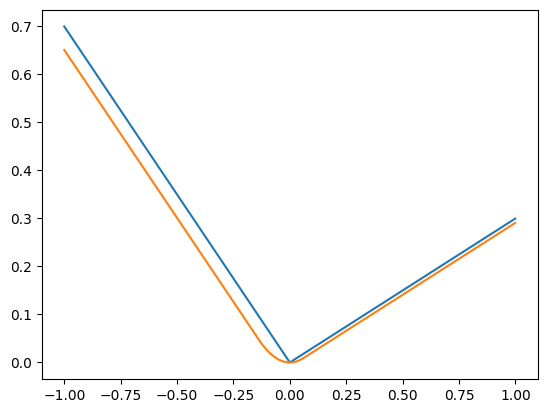

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(-1, 1, 0.001)


def caviar_loss(x):
    return -1*(float(x < 0) - 0.3) * x

def caviar_loss_2(x):
    return -1*(float(x < 0) - 0.025) * huber_loss(x) * torch.sign(x)


def huber_loss(x, eps=0.025):
    if torch.abs(x) <= eps:
        return torch.square(x) / 2
    else:
        return eps * (torch.abs(x) - 1 / 2 * eps)


def other_huber_loss(x, pval=0.3, eps=0.2):
    # x = true - var

    if x <= (pval-1)*eps:
        return x*(pval - 1) - 1/2*(pval - 1)**2 * eps
    elif x <= pval * eps:
        return x**2/(2*eps)
    else:
        return x*pval - 1/2*pval**2 * eps


pred = []
pred2 = []
for i in range(len(x)):
    pred.append(caviar_loss(torch.from_numpy(x)[i]))
    pred2.append(other_huber_loss(torch.from_numpy(x)[i]))

# for i in range(len(x)):
#     pred.append(torch.from_numpy(x)[i])
#     pred2.append(1/0.025*huber_loss(torch.from_numpy(x)[i])*torch.sign(torch.from_numpy(x)[i]))

plt.plot(x, pred)
plt.plot(x, pred2)
plt.show()